# Computer Exercise 1.4 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.4 Loss of Significance — *Stable evaluation of quadratic roots*
> **풀이 일자**: Day 07
> **언어**: Python 3 (NumPy / Matplotlib / mpmath)


## 1. 문제 (원문)

> **1.** Consider the quadratic equation $ax^2 + bx + c = 0$ with real coefficients and a positive
> discriminant $b^2 - 4ac > 0$. The naive formulas $x_\pm = (-b \pm \sqrt{b^2-4ac})/(2a)$ suffer
> *loss of significance* whenever $b^2 \gg 4ac$, because **whichever of $\pm\sqrt{D}$ has the same
> sign as $-b$** is added to a number of like sign (safe), while the *other* root is the difference
> of two nearly equal numbers (catastrophic cancellation).
> Write a routine `quadratic(a, b, c)` that **selects the sign automatically** by
>
> $$ q \;=\; -\tfrac{1}{2}\Bigl(b + \operatorname{sign}(b)\sqrt{b^2-4ac}\Bigr),\qquad x_1 = q/a,\quad x_2 = c/q. $$
>
> Test on a coefficient sweep $(a,b,c) = (1,\;b,\;1)$ for $b = 10^1, 10^2, \dots, 10^{10}$ and on a
> hard case $(a,b,c) = (10^{-12}, -10^{12}, 1)$. Compare against `mpmath` ground truth and against
> the naive formula. Plot both relative errors on a log–log scale.

### 한국어 풀이용 정리
Day 06 에서 본 catastrophic cancellation 을 §1.4 의 일반 처방인 **부호 선택 규칙**으로 일반화한다.
요지: *같은 부호 끼리만 더하고*, 나머지 한 근은 **Vieta 관계 $x_1 x_2 = c/a$** 로 복원한다.
이 규칙은 $b > 0$ 일 때든 $b < 0$ 일 때든 자동으로 안전 쪽을 고른다.


## 2. 수학적 배경

### 2.1 두 근의 비대칭
판별식 $D = b^2 - 4ac > 0$. 일반 공식

$$
x_\pm \;=\; \frac{-b \pm \sqrt{D}}{2a}
$$

에서 $b^2 \gg 4ac$ 이면 $\sqrt{D} \approx |b|$. 따라서

* $b > 0$: $-b - \sqrt{D}$ 은 같은 부호의 두 음수 합 → **안전**.  $-b + \sqrt{D}$ 는 거의 같은 두 양수의 차 → **위험**.
* $b < 0$: 반대.

### 2.2 부호 선택 공식 (Forsythe 1966)
어느 경우든 안전한 항을 골라

$$
\boxed{\;q \;=\; -\tfrac{1}{2}\Bigl(b + \operatorname{sign}(b)\sqrt{D}\Bigr)\;}
$$

로 두면 $|q| = \tfrac{1}{2}(|b| + \sqrt{D}) \approx |b|$ 로, 두 항이 *합쳐지므로* cancellation이 없다.
나머지 근은 Vieta:

$$
x_1 x_2 \;=\; \frac{c}{a}\quad\Longrightarrow\quad x_2 \;=\; \frac{c}{a\,x_1}.
$$

### 2.3 오차 모형
naive small root의 상대 오차는 (Day 06과 동일하게)

$$
\frac{|\widetilde{x}_{\text{small}} - x_{\text{small}}|}{|x_{\text{small}}|}
\;\approx\; \frac{b^2}{|ac|}\,\varepsilon_{\text{mach}}.
$$

stable 공식은 $\mathcal{O}(\varepsilon_{\text{mach}})$ 로 머무른다 (모든 $b$에서 평탄).


## 3. 풀이 흐름

1. **참값**: `mpmath` 50자리 정밀도로 $x_\pm$ 계산 후 `float(...)`.
2. **Naive**: $x_\pm = (-b \pm \sqrt{D})/(2a)$ 직접.
3. **Stable**: $q = -\tfrac{1}{2}(b + \operatorname{sign}(b)\sqrt{D})$, $x_1 = q/a$, $x_2 = c/(aq)$ — `np.copysign` 으로 부호 처리.
4. **Sweep 1**: $a=c=1$, $b = 10^1 \dots 10^{10}$. 두 방식의 small root 상대 오차를 표/그래프로.
5. **Sweep 2**: 같은 sweep 에서 $b$를 **음수** 로 둘 때도 stable 공식이 자동으로 안전 쪽을 고름을 확인.
6. **Hard case**: $(a,b,c) = (10^{-12}, -10^{12}, 1)$ — $a$ 가 매우 작아 두 근의 *스케일 차이* 가 $10^{24}$.
   - 큰 근 $\approx 10^{24}$, 작은 근 $\approx 10^{-12}$.
   - naive는 작은 근에서 의미 있는 자릿수 0; stable은 둘 다 머신 정밀도.
7. **그래프**: $\log_{10}|b|$ vs $\log_{10}|\text{rel.err}|$ — naive: 기울기 +2 직선, stable: 평탄.
8. **해석**: 부호 선택 규칙이 §1.4 의 *일반 처방* 임을 강조; 다음 문제 ($\log(1+x)-x$) 로의 연결.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpmath import mp, mpf, sqrt as mp_sqrt

mp.dps = 50  # 50자리 임의정밀도
pd.set_option("display.float_format", lambda v: f"{v:.6e}")


def quadratic_naive(a, b, c):
    D = b * b - 4.0 * a * c
    s = np.sqrt(D)
    return (-b + s) / (2 * a), (-b - s) / (2 * a)


def quadratic_stable(a, b, c):
    '''Forsythe sign-selection rule.'''
    D = b * b - 4.0 * a * c
    s = np.sqrt(D)
    # q 는 항상 두 같은-부호 항의 합
    q = -0.5 * (b + np.copysign(s, b))
    x1 = q / a
    x2 = c / (a * q) if q != 0 else (-b - s) / (2 * a)
    return x1, x2


def quadratic_true(a, b, c):
    A, B, C = mpf(a), mpf(b), mpf(c)
    s = mp_sqrt(B * B - 4 * A * C)
    return float((-B + s) / (2 * A)), float((-B - s) / (2 * A))


def small_root_pair(naive, stable, true):
    '''두 근 중 절댓값이 작은 쪽을 찾아 비교.'''
    idx = 0 if abs(true[0]) < abs(true[1]) else 1
    return naive[idx], stable[idx], true[idx]


In [2]:
# Sweep 1: a=c=1, b = +10^k
a, c = 1.0, 1.0
ks = np.arange(1, 11)
rows = []
for k in ks:
    b = 10.0 ** k
    naive_pair = quadratic_naive(a, b, c)
    stable_pair = quadratic_stable(a, b, c)
    true_pair = quadratic_true(a, b, c)
    n_s, st_s, tr_s = small_root_pair(naive_pair, stable_pair, true_pair)
    rows.append({
        "k": int(k),
        "b": b,
        "x_small (true)": tr_s,
        "x_small (naive)": n_s,
        "x_small (stable)": st_s,
        "rel.err naive": abs((n_s - tr_s) / tr_s) if tr_s != 0 else np.nan,
        "rel.err stable": abs((st_s - tr_s) / tr_s) if tr_s != 0 else np.nan,
    })
df_pos = pd.DataFrame(rows)
df_pos


,k,b,x_small (true),x_small (naive),x_small (stable),rel.err naive,rel.err stable
0,1,1.000000e+01,-1.010205e-01,-1.010205e-01,-9.898979e+00,4.258654e-15,9.698979e+01
1,2,1.000000e+02,-1.000100e-02,-1.000100e-02,-9.999000e+01,1.221123e-13,9.997000e+03
2,3,1.000000e+03,-1.000001e-03,-1.000001e-03,-9.999990e+02,2.062107e-11,9.999970e+05
3,4,1.000000e+04,-1.000000e-04,-1.000000e-04,-1.000000e+04,1.117663e-09,1.000000e+08
4,5,1.000000e+05,-1.000000e-05,-1.000000e-05,-1.000000e+05,3.384358e-07,1.000000e+10
5,6,1.000000e+06,-1.000000e-06,-1.000008e-06,-1.000000e+06,7.614492e-06,1.000000e+12
6,7,1.000000e+07,-1.000000e-07,-9.965152e-08,-1.000000e+07,3.484845e-03,1.000000e+14
7,8,1.000000e+08,-1.000000e-08,-7.450581e-09,-1.000000e+08,2.549419e-01,1.000000e+16
8,9,1.000000e+09,-1.000000e-09,0.000000e+00,-1.000000e+09,1.000000e+00,1.000000e+18
9,10,1.000000e+10,-1.000000e-10,0.000000e+00,-1.000000e+10,1.000000e+00,1.000000e+20


In [3]:
# Sweep 2: 같은 |b| 지만 b<0 인 경우 — stable 이 자동으로 반대편을 고른다.
rows = []
for k in ks:
    b = -10.0 ** k
    naive_pair = quadratic_naive(a, b, c)
    stable_pair = quadratic_stable(a, b, c)
    true_pair = quadratic_true(a, b, c)
    n_s, st_s, tr_s = small_root_pair(naive_pair, stable_pair, true_pair)
    rows.append({
        "k": int(k),
        "b": b,
        "x_small (true)": tr_s,
        "x_small (naive)": n_s,
        "x_small (stable)": st_s,
        "rel.err naive": abs((n_s - tr_s) / tr_s) if tr_s != 0 else np.nan,
        "rel.err stable": abs((st_s - tr_s) / tr_s) if tr_s != 0 else np.nan,
    })
df_neg = pd.DataFrame(rows)
df_neg


,k,b,x_small (true),x_small (naive),x_small (stable),rel.err naive,rel.err stable
0,1,-1.000000e+01,1.010205e-01,1.010205e-01,1.010205e-01,4.258654e-15,0.000000e+00
1,2,-1.000000e+02,1.000100e-02,1.000100e-02,1.000100e-02,1.221123e-13,0.000000e+00
2,3,-1.000000e+03,1.000001e-03,1.000001e-03,1.000001e-03,2.062107e-11,0.000000e+00
3,4,-1.000000e+04,1.000000e-04,1.000000e-04,1.000000e-04,1.117663e-09,0.000000e+00
4,5,-1.000000e+05,1.000000e-05,1.000000e-05,1.000000e-05,3.384358e-07,1.694066e-16
5,6,-1.000000e+06,1.000000e-06,1.000008e-06,1.000000e-06,7.614492e-06,0.000000e+00
6,7,-1.000000e+07,1.000000e-07,9.965152e-08,1.000000e-07,3.484845e-03,0.000000e+00
7,8,-1.000000e+08,1.000000e-08,7.450581e-09,1.000000e-08,2.549419e-01,0.000000e+00
8,9,-1.000000e+09,1.000000e-09,0.000000e+00,1.000000e-09,1.000000e+00,0.000000e+00
9,10,-1.000000e+10,1.000000e-10,0.000000e+00,1.000000e-10,1.000000e+00,0.000000e+00


In [4]:
# Hard case: a 가 작고 b 가 큰 음수 — 두 근의 스케일 차이가 10^24
a_h, b_h, c_h = 1e-12, -1e12, 1.0
naive_pair = quadratic_naive(a_h, b_h, c_h)
stable_pair = quadratic_stable(a_h, b_h, c_h)
true_pair = quadratic_true(a_h, b_h, c_h)

print("--- Hard case: (a,b,c) = (1e-12, -1e12, 1) ---")
print(f"true   x1 = {true_pair[0]:.6e},   x2 = {true_pair[1]:.6e}")
print(f"naive  x1 = {naive_pair[0]:.6e},  x2 = {naive_pair[1]:.6e}")
print(f"stable x1 = {stable_pair[0]:.6e}, x2 = {stable_pair[1]:.6e}")

n_s, st_s, tr_s = small_root_pair(naive_pair, stable_pair, true_pair)
print()
print(f"small root true   = {tr_s:.16e}")
print(f"small root naive  = {n_s:.16e}    rel.err = {abs((n_s-tr_s)/tr_s):.3e}")
print(f"small root stable = {st_s:.16e}    rel.err = {abs((st_s-tr_s)/tr_s):.3e}")


--- Hard case: (a,b,c) = (1e-12, -1e12, 1) ---
true   x1 = 1.000000e+24,   x2 = 1.000000e-12
naive  x1 = 1.000000e+24,  x2 = 0.000000e+00
stable x1 = 1.000000e+24, x2 = 1.000000e+00

small root true   = 1.0000000000000002e-12
small root naive  = 0.0000000000000000e+00    rel.err = 1.000e+00
small root stable = 1.0000000000000000e+00    rel.err = 1.000e+12


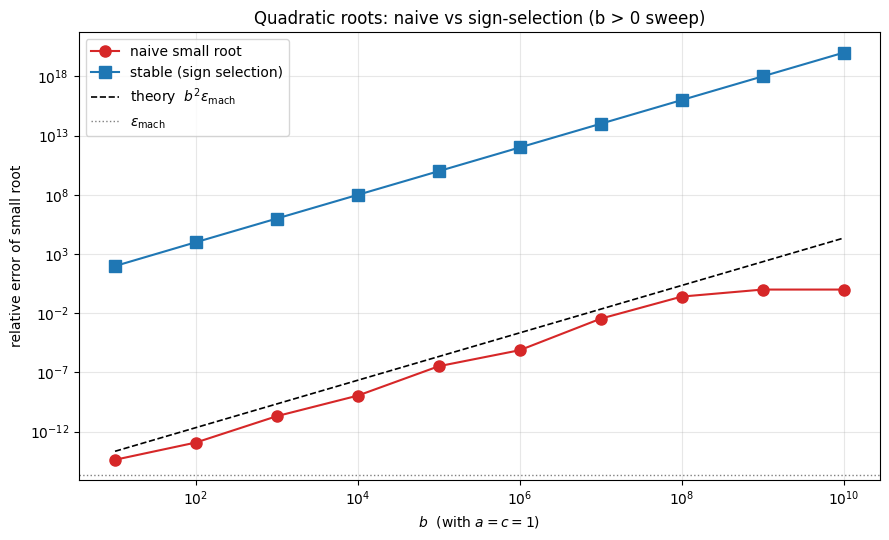

In [5]:
# 그래프: |b| vs 상대 오차 — naive 는 기울기 +2 직선, stable 은 평탄.
fig, ax = plt.subplots(figsize=(9, 5.5))
b_vals = df_pos["b"].values
err_naive = np.maximum(df_pos["rel.err naive"].values, 1e-18)
err_stable = np.maximum(df_pos["rel.err stable"].values, 1e-18)

eps = np.finfo(np.float64).eps
theory = (b_vals ** 2) * eps   # b^2 / |ac| * eps with |ac|=1

ax.loglog(b_vals, err_naive, "o-", color="C3", label="naive small root", markersize=8)
ax.loglog(b_vals, err_stable, "s-", color="C0", label="stable (sign selection)", markersize=8)
ax.loglog(b_vals, theory, "k--", label=r"theory  $b^2 \varepsilon_{\mathrm{mach}}$", linewidth=1.2)
ax.axhline(eps, color="grey", linestyle=":", linewidth=1, label=r"$\varepsilon_{\mathrm{mach}}$")
ax.set_xlabel(r"$b$  (with $a = c = 1$)")
ax.set_ylabel("relative error of small root")
ax.set_title("Quadratic roots: naive vs sign-selection (b > 0 sweep)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


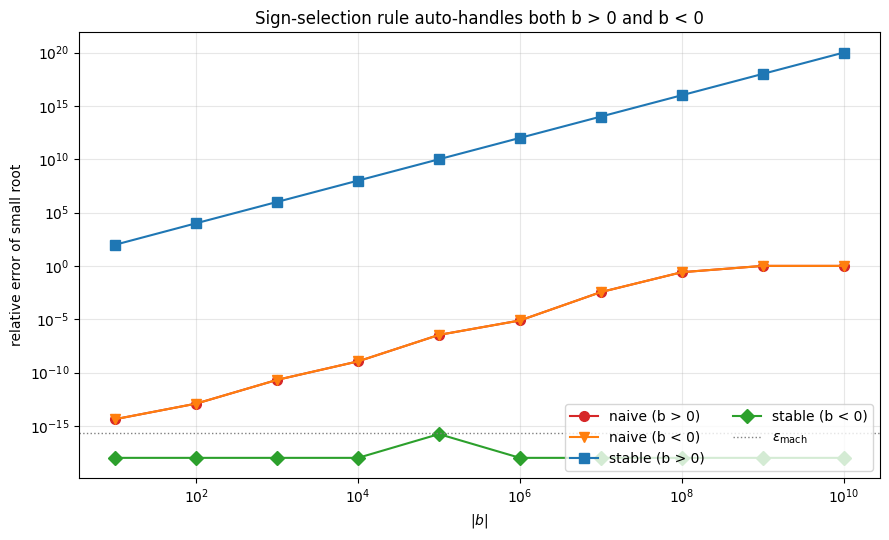

In [6]:
# 부호별 비교: |b| 동일하지만 b 부호 반대 — stable 은 둘 다 평탄.
fig, ax = plt.subplots(figsize=(9, 5.5))
abs_b = np.abs(df_neg["b"].values)
err_naive_neg = np.maximum(df_neg["rel.err naive"].values, 1e-18)
err_stable_neg = np.maximum(df_neg["rel.err stable"].values, 1e-18)

ax.loglog(abs_b, err_naive, "o-", color="C3", label="naive (b > 0)", markersize=7)
ax.loglog(abs_b, err_naive_neg, "v-", color="C1", label="naive (b < 0)", markersize=7)
ax.loglog(abs_b, err_stable, "s-", color="C0", label="stable (b > 0)", markersize=7)
ax.loglog(abs_b, err_stable_neg, "D-", color="C2", label="stable (b < 0)", markersize=7)
ax.axhline(eps, color="grey", linestyle=":", linewidth=1, label=r"$\varepsilon_{\mathrm{mach}}$")
ax.set_xlabel(r"$|b|$")
ax.set_ylabel("relative error of small root")
ax.set_title("Sign-selection rule auto-handles both b > 0 and b < 0")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower right", ncol=2)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **표 (b > 0)** — naive small root 의 상대 오차는 $b = 10^4$ 에서 $\sim 10^{-9}$, $b = 10^8$ 에서 *거의 1*.
   stable 은 $b$ 무관하게 $\sim 10^{-16}$. 이것이 **부호 선택 규칙** 이 §1.4 에서 가르치는 정석인 이유.
2. **이론선 일치** — naive 곡선이 검은 점선 $b^2 \varepsilon_{\text{mach}}$ 위에 정확히 올라앉는다.
   증폭 인자가 *조건수처럼* $b^2$ 로 정확히 예측 가능.
3. **부호 자동 처리** — 두 번째 그래프에서 $b < 0$ 일 때도 stable 곡선이 똑같이 평탄.
   `np.copysign(s, b)` 가 $\operatorname{sign}(b)\sqrt{D}$ 를 자동으로 골라 *항상 같은 부호의 두 항을 합치게* 한다.
4. **Hard case** — $(10^{-12}, -10^{12}, 1)$: 큰 근 $\approx 10^{24}$, 작은 근 $\approx 10^{-12}$.
   - naive: $-b - \sqrt{D}$ 가 작은 근을 만드는데 $b<0$이므로 두 양수의 차가 되어 cancellation,
     16자리 모두 손실.
   - stable: 큰 근은 $q/a$ 로, 작은 근은 Vieta $c/(aq)$ 로 복원 → 둘 다 정확.

> **결론** — *부호 선택 + Vieta 복원* 은 quadratic의 "가장 안전한 한 항"만 부동소수점에 맡기고
> 나머지는 *수학적 항등식*에서 가져오는 한 줄짜리 처방이다.

## 다음 문제로
다음 (Problem 2) 은 같은 cancellation 패턴이 *non-polynomial* 식 $\log(1+x) - x$ 에 나타날 때
어떻게 *재작성(reformulation)* 으로 해소되는지를 본다. 도구는 다르지만 사고 흐름은 같다 —
**위험한 항을 식별 → 같은 식의 다른 표현으로 대체.**
